# 通道去耦合測試

此 notebook 用於測試和調整通道去耦合參數

## 主要功能
1. 讀取測試影像
2. 分離紅綠通道
3. 測試不同的 alpha 參數
4. 比較固定 vs 自適應策略
5. 視覺化結果

## 1. 導入必要的套件

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

# 添加專案路徑
project_root = Path().absolute().parent.parent
sys.path.insert(0, str(project_root))

# 導入處理模組
from preprocessing.channel_decoupling import ChannelDecoupler
from preprocessing.config import ChannelDecouplingConfig
from preprocessing.image_loader import ImageLoader

# 設定 matplotlib 中文顯示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("✓ 套件導入完成")

✓ 套件導入完成


## 2. 載入測試影像

In [2]:
# 設定影像路徑（請修改為你的測試影像路徑）
IMAGE_PATH = "/Users/ponywen/projects/ienf_q/data/Original/S163-2_a.tif"  # 請修改此路徑

# 使用 ImageLoader 載入影像
loader = ImageLoader()
image_data = loader.load(IMAGE_PATH)

print(f"影像尺寸: {image_data.shape}")
print(f"數據類型: {image_data.dtype}")
print(f"數值範圍: [{image_data.min()}, {image_data.max()}]")

✓ 載入圖像: S163-2_a.tif
  - 尺寸: (1028, 4713, 3)
  - 類型: uint8
  - 範圍: [0, 255]
影像尺寸: (1028, 4713, 3)
數據類型: uint8
數值範圍: [0, 255]


## 3. 分離紅綠通道

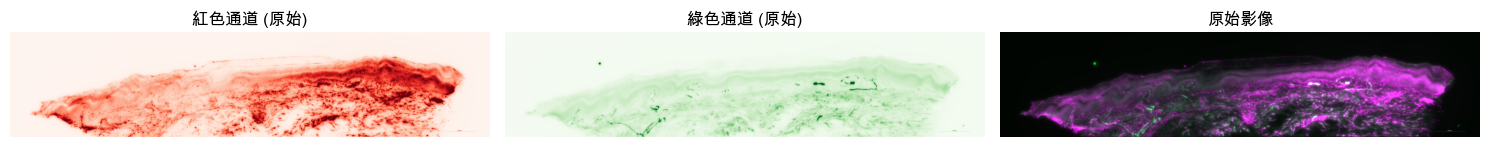

紅色通道 - 範圍: [0, 254]
綠色通道 - 範圍: [0, 254]


In [3]:
# 分離通道 (假設是 RGB 或多通道影像)
if len(image_data.shape) == 3:
    # 如果是彩色影像
    if image_data.shape[2] >= 3:
        red_channel = image_data[:, :, 0]  # 紅色通道
        green_channel = image_data[:, :, 1]  # 綠色通道
    else:
        print("警告: 影像通道數不足")
elif len(image_data.shape) == 2:
    # 如果是灰階影像，假設它是綠色通道
    print("警告: 檢測到灰階影像，需要提供紅色通道")
    green_channel = image_data
    red_channel = np.zeros_like(green_channel)  # 創建空的紅色通道

# 顯示原始通道
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title('紅色通道 (原始)')
axes[0].axis('off')

axes[1].imshow(green_channel, cmap='Greens')
axes[1].set_title('綠色通道 (原始)')
axes[1].axis('off')

axes[2].imshow(image_data)
axes[2].set_title('原始影像')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"紅色通道 - 範圍: [{red_channel.min()}, {red_channel.max()}]")
print(f"綠色通道 - 範圍: [{green_channel.min()}, {green_channel.max()}]")

## 4. 測試固定 alpha 值

Alpha 0.0: 範圍 [0.0, 254.0], 平均 30.0, 標準差 26.4
Alpha 0.1: 範圍 [0.0, 253.0], 平均 24.4, 標準差 22.0
Alpha 0.2: 範圍 [0.0, 253.0], 平均 19.4, 標準差 18.2
Alpha 0.3: 範圍 [0.0, 253.0], 平均 14.7, 標準差 15.5
Alpha 0.4: 範圍 [0.0, 253.0], 平均 11.0, 標準差 13.2
Alpha 0.5: 範圍 [0.0, 253.0], 平均 8.3, 標準差 11.1


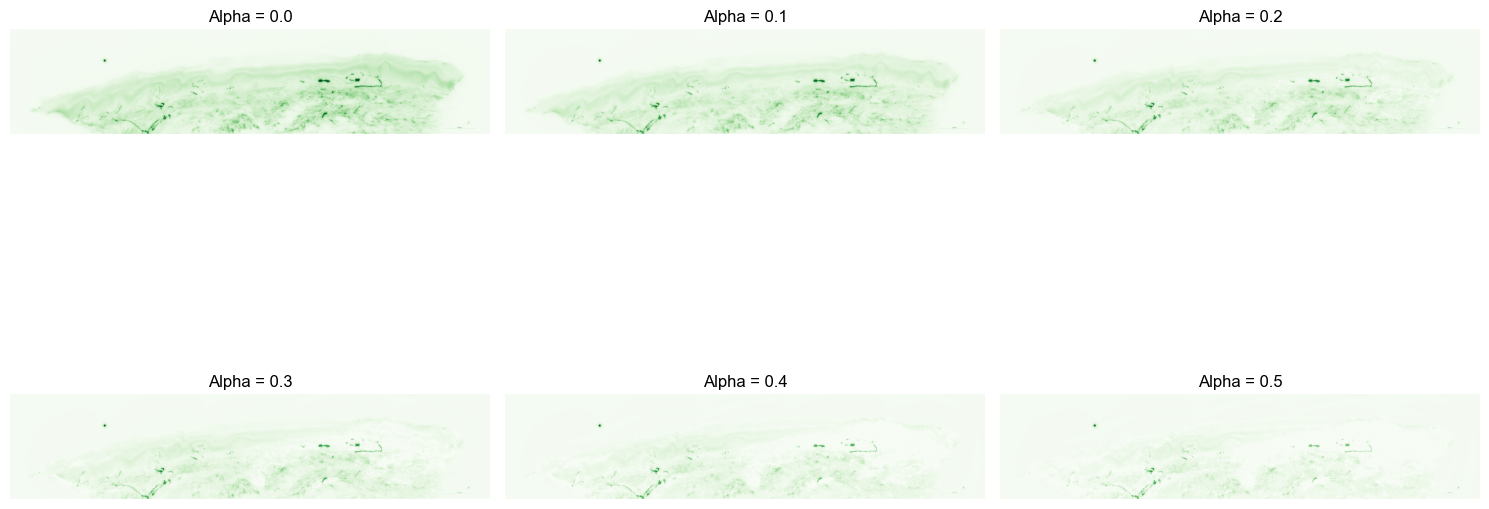

In [4]:
# 測試不同的 alpha 值
alpha_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, alpha in enumerate(alpha_values):
    # 創建配置
    config = ChannelDecouplingConfig(
        alpha=alpha,
        adaptive=False
    )
    
    # 應用去耦合
    decoupler = ChannelDecoupler(config)
    corrected = decoupler.process(green_channel, red_channel)
    
    # 顯示結果
    axes[idx].imshow(corrected, cmap='Greens')
    axes[idx].set_title(f'Alpha = {alpha}')
    axes[idx].axis('off')
    
    # 顯示統計資訊
    print(f"Alpha {alpha}: 範圍 [{corrected.min():.1f}, {corrected.max():.1f}], "
          f"平均 {corrected.mean():.1f}, 標準差 {corrected.std():.1f}")

plt.tight_layout()
plt.show()

## 5. 詳細比較：原始 vs 校正後

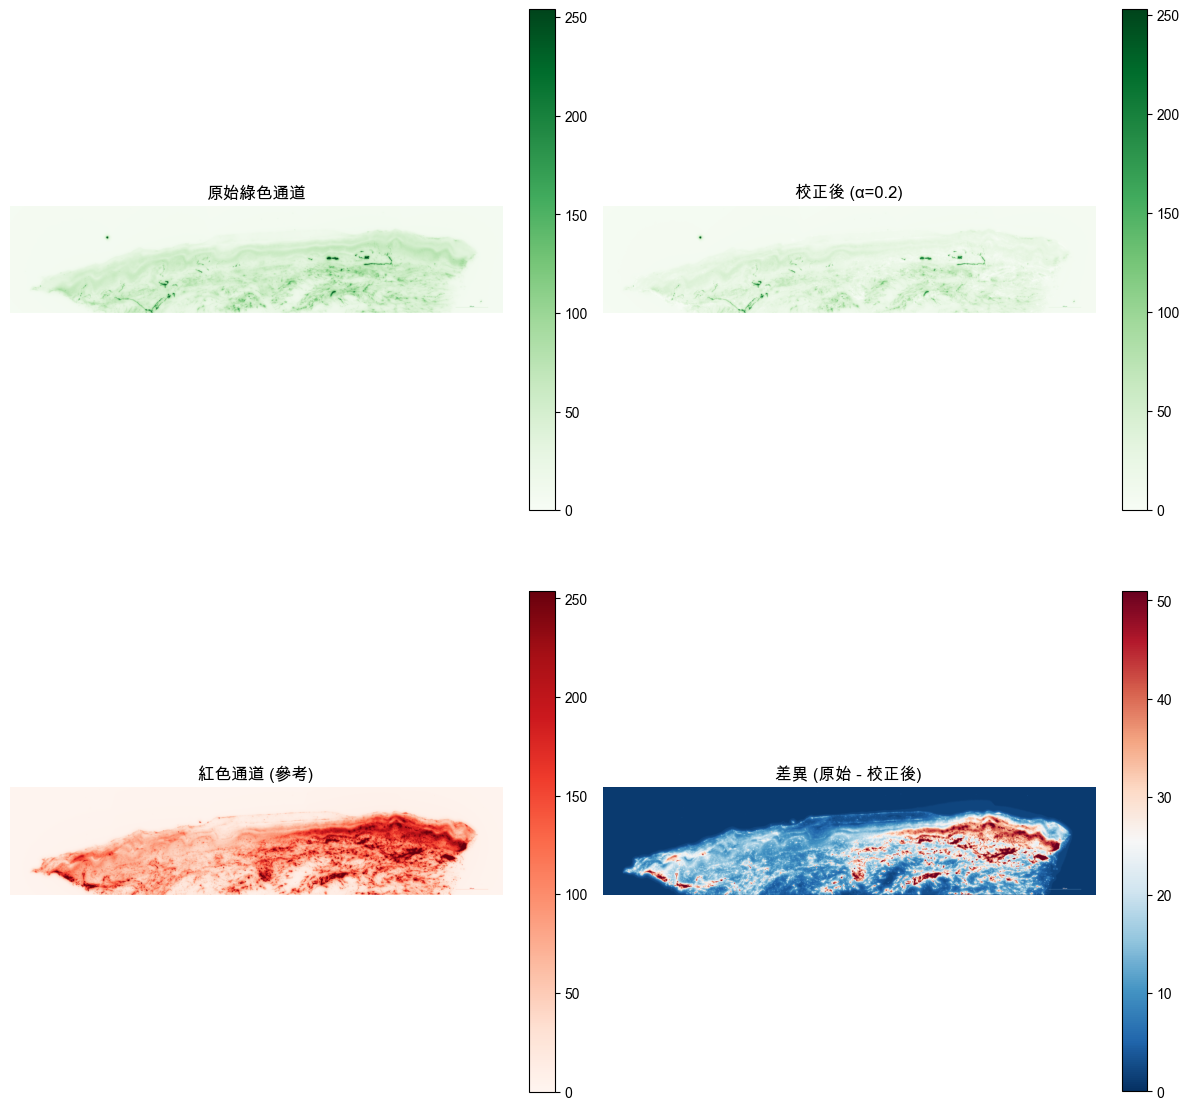


統計資訊:
原始 - 平均: 30.00, 標準差: 26.41
校正 - 平均: 19.45, 標準差: 18.19
差異 - 平均: 10.55, 標準差: 11.87


In [5]:
# 選擇最佳的 alpha 值進行詳細比較
BEST_ALPHA = 0.2  # 根據上面的結果調整

config = ChannelDecouplingConfig(alpha=BEST_ALPHA, adaptive=False)
decoupler = ChannelDecoupler(config)
corrected = decoupler.process(green_channel, red_channel)

# 計算差異
difference = green_channel.astype(float) - corrected.astype(float)

# 顯示比較
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 原始綠色通道
im0 = axes[0, 0].imshow(green_channel, cmap='Greens')
axes[0, 0].set_title('原始綠色通道')
axes[0, 0].axis('off')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

# 校正後的綠色通道
im1 = axes[0, 1].imshow(corrected, cmap='Greens')
axes[0, 1].set_title(f'校正後 (α={BEST_ALPHA})')
axes[0, 1].axis('off')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

# 紅色通道參考
im2 = axes[1, 0].imshow(red_channel, cmap='Reds')
axes[1, 0].set_title('紅色通道 (參考)')
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

# 差異圖
im3 = axes[1, 1].imshow(difference, cmap='RdBu_r')
axes[1, 1].set_title('差異 (原始 - 校正後)')
axes[1, 1].axis('off')
plt.colorbar(im3, ax=axes[1, 1], fraction=0.046)

plt.tight_layout()
plt.show()

print(f"\n統計資訊:")
print(f"原始 - 平均: {green_channel.mean():.2f}, 標準差: {green_channel.std():.2f}")
print(f"校正 - 平均: {corrected.mean():.2f}, 標準差: {corrected.std():.2f}")
print(f"差異 - 平均: {difference.mean():.2f}, 標準差: {difference.std():.2f}")

## 6. 測試自適應 alpha

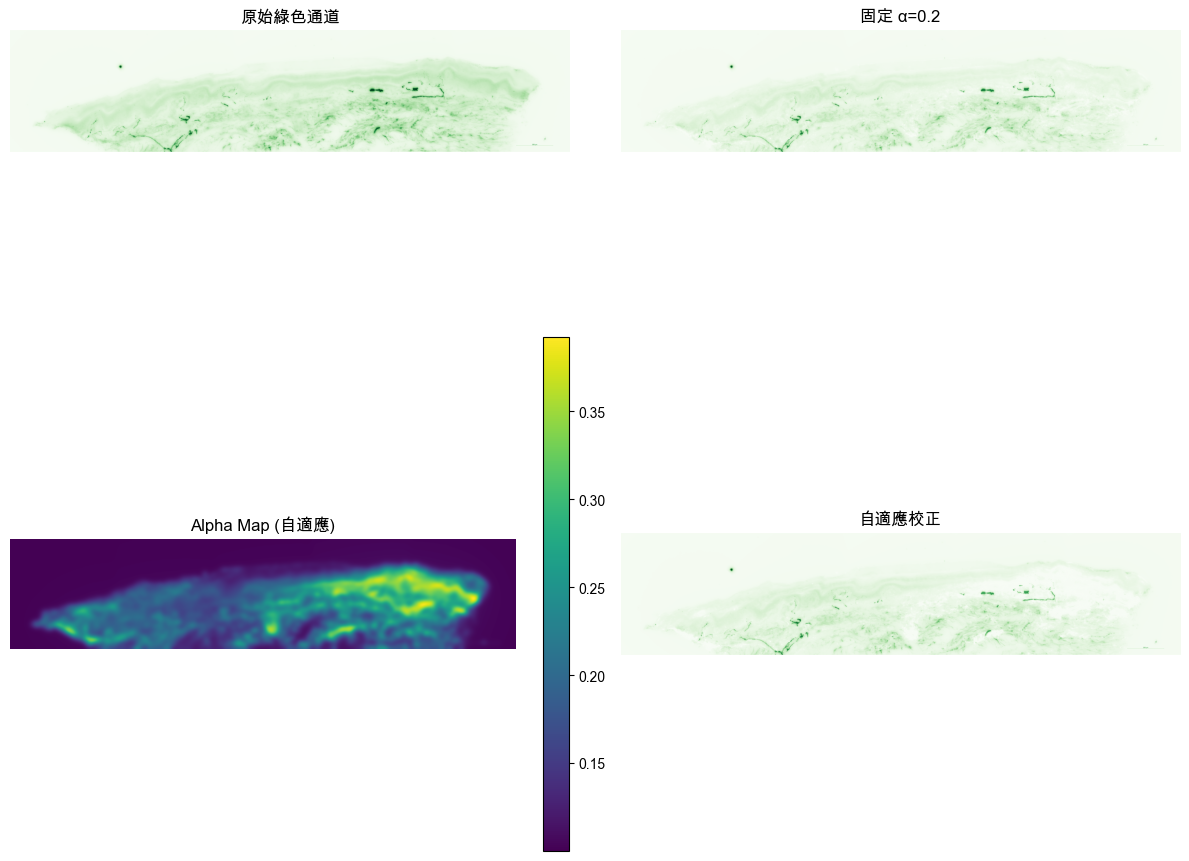


Alpha Map 統計:
範圍: [0.100, 0.393]
平均: 0.164

自適應校正統計:
平均: 17.69
標準差: 17.77


In [6]:
# 使用自適應策略
config_adaptive = ChannelDecouplingConfig(
    alpha=0.2,  # 基礎 alpha
    adaptive=True,
    alpha_min=0.1,  # 最小 alpha (紅色密度低的區域)
    alpha_max=0.4   # 最大 alpha (紅色密度高的區域)
)

decoupler_adaptive = ChannelDecoupler(config_adaptive)
corrected_adaptive = decoupler_adaptive.process(green_channel, red_channel)

# 計算 alpha map (用於視覺化)
alpha_map = decoupler_adaptive._calculate_adaptive_alpha(red_channel)

# 顯示結果
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# 原始綠色通道
axes[0, 0].imshow(green_channel, cmap='Greens')
axes[0, 0].set_title('原始綠色通道')
axes[0, 0].axis('off')

# 固定 alpha 校正
axes[0, 1].imshow(corrected, cmap='Greens')
axes[0, 1].set_title(f'固定 α={BEST_ALPHA}')
axes[0, 1].axis('off')

# Alpha map 視覺化
im2 = axes[1, 0].imshow(alpha_map, cmap='viridis')
axes[1, 0].set_title('Alpha Map (自適應)')
axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], fraction=0.046)

# 自適應 alpha 校正
axes[1, 1].imshow(corrected_adaptive, cmap='Greens')
axes[1, 1].set_title('自適應校正')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print(f"\nAlpha Map 統計:")
print(f"範圍: [{alpha_map.min():.3f}, {alpha_map.max():.3f}]")
print(f"平均: {alpha_map.mean():.3f}")
print(f"\n自適應校正統計:")
print(f"平均: {corrected_adaptive.mean():.2f}")
print(f"標準差: {corrected_adaptive.std():.2f}")

## 7. 比較固定 vs 自適應策略

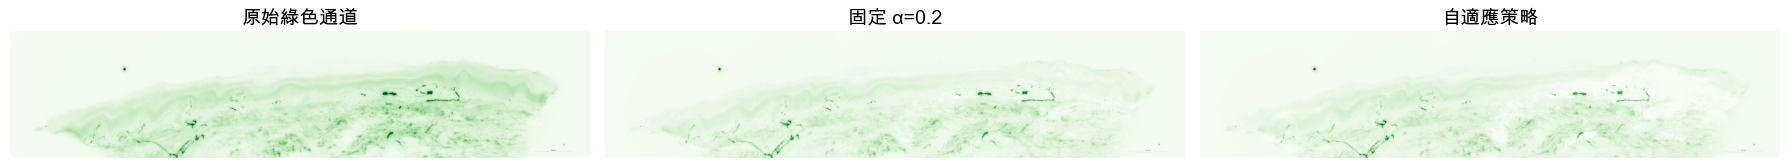

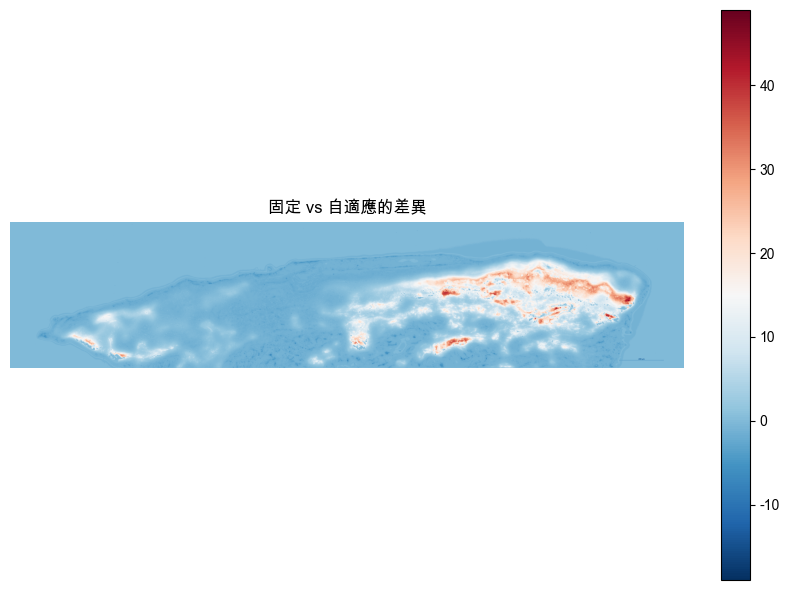

固定 vs 自適應差異統計:
平均差異: 1.76
標準差: 5.51
最大差異: 49.00


In [7]:
# 並排比較
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(green_channel, cmap='Greens')
axes[0].set_title('原始綠色通道', fontsize=14)
axes[0].axis('off')

axes[1].imshow(corrected, cmap='Greens')
axes[1].set_title(f'固定 α={BEST_ALPHA}', fontsize=14)
axes[1].axis('off')

axes[2].imshow(corrected_adaptive, cmap='Greens')
axes[2].set_title('自適應策略', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 計算兩種方法的差異
diff_fixed_adaptive = corrected.astype(float) - corrected_adaptive.astype(float)

plt.figure(figsize=(8, 6))
plt.imshow(diff_fixed_adaptive, cmap='RdBu_r')
plt.title('固定 vs 自適應的差異')
plt.colorbar(fraction=0.046)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"固定 vs 自適應差異統計:")
print(f"平均差異: {diff_fixed_adaptive.mean():.2f}")
print(f"標準差: {diff_fixed_adaptive.std():.2f}")
print(f"最大差異: {abs(diff_fixed_adaptive).max():.2f}")

## 8. 直方圖分析

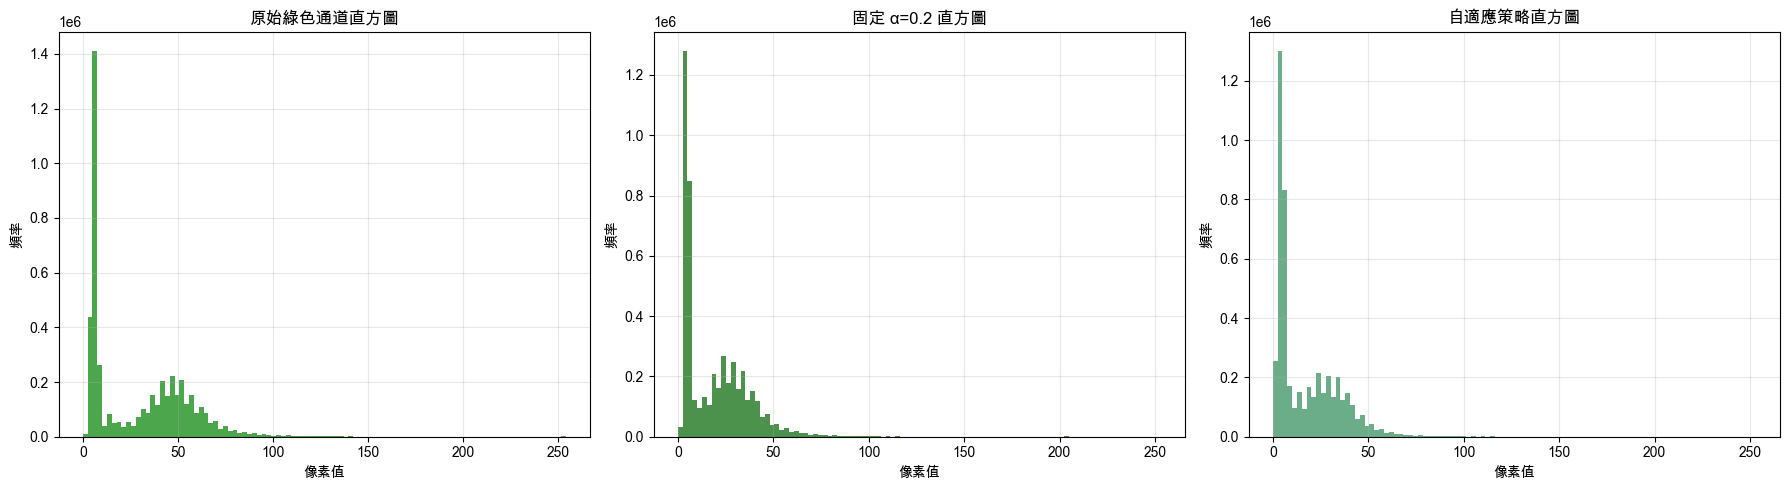

In [8]:
# 比較不同處理方法的直方圖
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 原始
axes[0].hist(green_channel.flatten(), bins=100, color='green', alpha=0.7)
axes[0].set_title('原始綠色通道直方圖')
axes[0].set_xlabel('像素值')
axes[0].set_ylabel('頻率')
axes[0].grid(True, alpha=0.3)

# 固定 alpha
axes[1].hist(corrected.flatten(), bins=100, color='darkgreen', alpha=0.7)
axes[1].set_title(f'固定 α={BEST_ALPHA} 直方圖')
axes[1].set_xlabel('像素值')
axes[1].set_ylabel('頻率')
axes[1].grid(True, alpha=0.3)

# 自適應
axes[2].hist(corrected_adaptive.flatten(), bins=100, color='seagreen', alpha=0.7)
axes[2].set_title('自適應策略直方圖')
axes[2].set_xlabel('像素值')
axes[2].set_ylabel('頻率')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. 局部區域分析

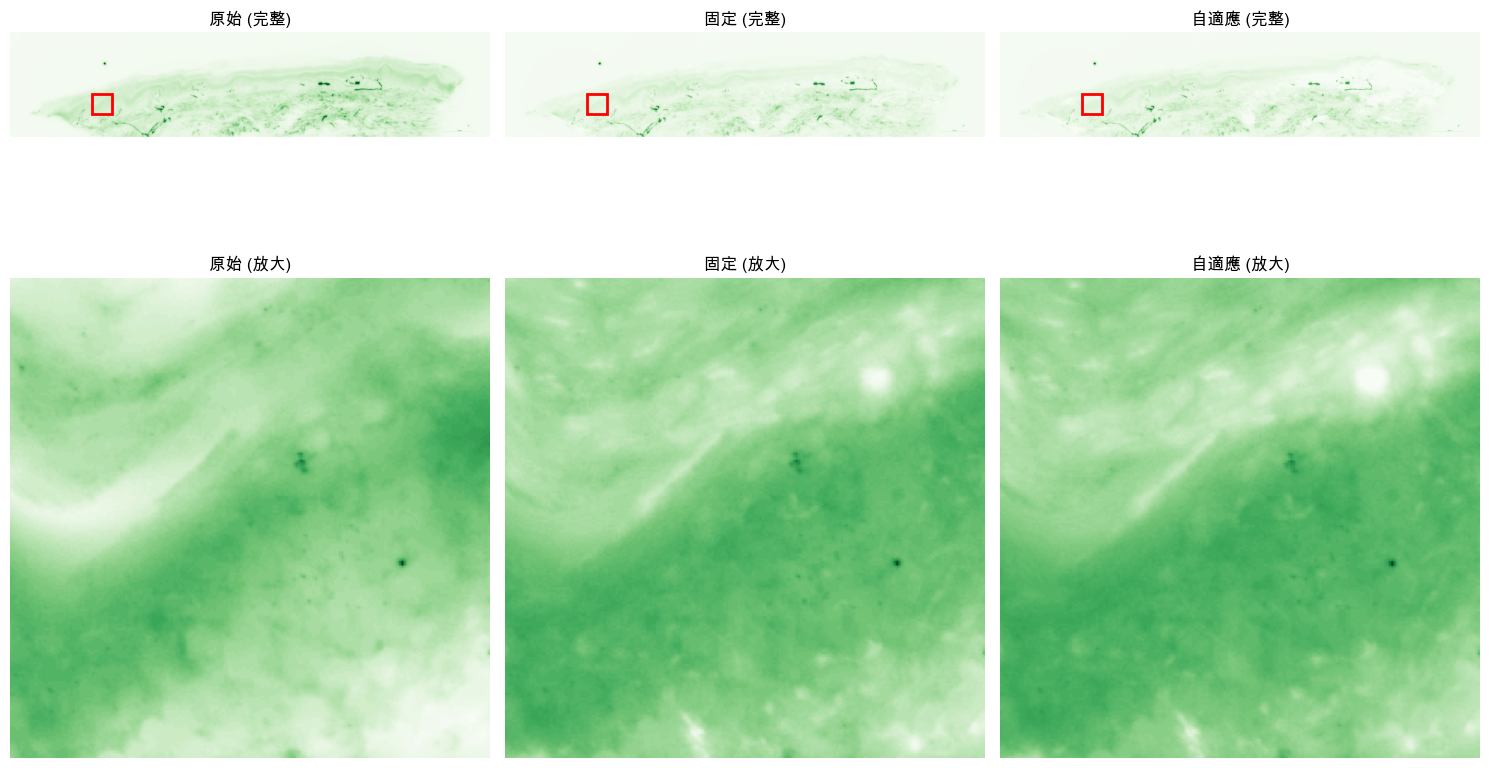

In [9]:
# 選擇感興趣的區域進行放大比較
# 請根據你的影像調整這些座標
y_start, y_end = 600, 800  # 修改這些值來選擇不同區域
x_start, x_end = 800, 1000

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 第一行：完整影像
axes[0, 0].imshow(green_channel, cmap='Greens')
axes[0, 0].set_title('原始 (完整)')
axes[0, 0].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start, 
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 0].axis('off')

axes[0, 1].imshow(corrected, cmap='Greens')
axes[0, 1].set_title('固定 (完整)')
axes[0, 1].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start, 
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 1].axis('off')

axes[0, 2].imshow(corrected_adaptive, cmap='Greens')
axes[0, 2].set_title('自適應 (完整)')
axes[0, 2].add_patch(plt.Rectangle((x_start, y_start), x_end-x_start, y_end-y_start, 
                                   fill=False, edgecolor='red', linewidth=2))
axes[0, 2].axis('off')

# 第二行：局部放大
axes[1, 0].imshow(green_channel[y_start:y_end, x_start:x_end], cmap='Greens')
axes[1, 0].set_title('原始 (放大)')
axes[1, 0].axis('off')

axes[1, 1].imshow(corrected[y_start:y_end, x_start:x_end], cmap='Greens')
axes[1, 1].set_title('固定 (放大)')
axes[1, 1].axis('off')

axes[1, 2].imshow(corrected_adaptive[y_start:y_end, x_start:x_end], cmap='Greens')
axes[1, 2].set_title('自適應 (放大)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

## 10. 保存結果

In [10]:
# 保存處理後的影像
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)

# 保存固定 alpha 結果
Image.fromarray(corrected).save(
    output_dir / f"corrected_fixed_alpha{BEST_ALPHA}_{timestamp}.png"
)

# 保存自適應結果
Image.fromarray(corrected_adaptive).save(
    output_dir / f"corrected_adaptive_{timestamp}.png"
)

# 保存 alpha map
alpha_map_normalized = ((alpha_map - alpha_map.min()) / (alpha_map.max() - alpha_map.min()) * 255).astype(np.uint8)
Image.fromarray(alpha_map_normalized).save(
    output_dir / f"alpha_map_{timestamp}.png"
)

print(f"✓ 結果已保存至 {output_dir}")
print(f"  - 固定 alpha: corrected_fixed_alpha{BEST_ALPHA}_{timestamp}.png")
print(f"  - 自適應: corrected_adaptive_{timestamp}.png")
print(f"  - Alpha map: alpha_map_{timestamp}.png")

✓ 結果已保存至 output
  - 固定 alpha: corrected_fixed_alpha0.2_20251018_220031.png
  - 自適應: corrected_adaptive_20251018_220031.png
  - Alpha map: alpha_map_20251018_220031.png


## 11. 參數調整建議

根據上面的視覺化結果，調整以下參數：

### 固定 alpha 策略
- **alpha**: 如果去耦合不足（仍看到紅色干擾），增加此值
- **alpha**: 如果過度校正（綠色信號變暗），減少此值
- 建議範圍: 0.1 - 0.4

### 自適應策略
- **alpha_min**: 控制紅色密度低區域的去耦合強度
- **alpha_max**: 控制紅色密度高區域的去耦合強度
- **sigma** (在 _calculate_adaptive_alpha 中): 控制密度計算的區域大小
  - 較大的 sigma → 更平滑的 alpha 變化
  - 較小的 sigma → 更局部的自適應

### 選擇策略
- 如果紅色干擾在整個影像中均勻分布 → 使用固定 alpha
- 如果紅色干擾強度有明顯的空間變化 → 使用自適應策略
- 如果不確定 → 比較兩種方法，選擇視覺效果更好的